# Notebook 3: TsSHAP vs TSICE Comparison

This notebook compares TsSHAP feature importances with TSICE (Time Series ICE) values.

TSICE computes Individual Conditional Expectation curves by perturbing each
lag position and measuring the forecast change.  TsSHAP uses SHAP values on a
surrogate model trained on interpretable features.

We compare them on:
1. **Rank correlation** of lag feature importances on synthetic data
2. **Visual side-by-side** bar charts (with the **forecaster name** as a figure suptitle where plots are shown)
3. **Correctness sanity check** — does the top-ranked lag match the forecaster's logic?
4. **All bundled forecasters** — after the guided Naive example, we repeat TsSHAP + TSICE under the **same pipeline** for Naive, Seasonal Naive, moving average, exponential smoothing, XGBoost, and Prophet (see README for optional dependencies and Prophet / `tsicebox` index caveats).

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from evaluation.synthetic_data import make_trend_seasonal
from evaluation.tsice_comparison import run_tsice, plot_comparison
from tsshap import TsSHAPExplainer
from tsshap.features import LagFeatures, SeasonalLagFeatures, STLFeatures, TrendFeatures
from tsshap.forecasters import (
    ExponentialSmoothingForecaster,
    MovingAverageForecaster,
    NaiveForecaster,
    ProphetForecaster,
    SeasonalNaiveForecaster,
    XGBoostForecaster,
)

## Setup: synthetic series with dominant lag-1 structure (Naive forecaster)
For a Naive forecaster, `y(t-1)` should dominate.  Both TsSHAP and TSICE should agree.

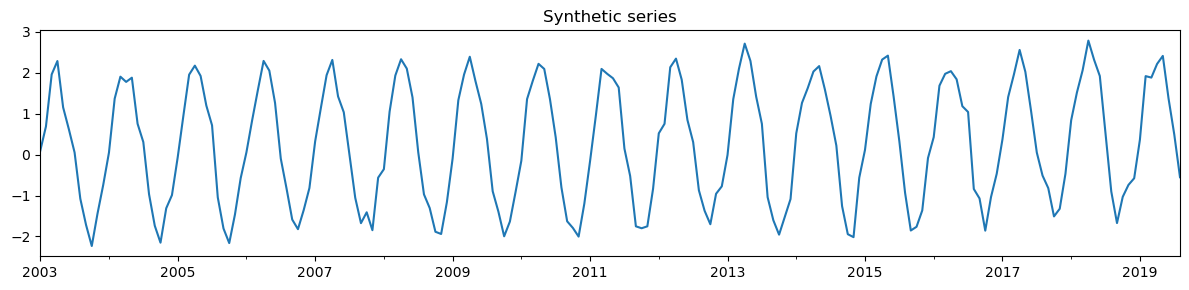

In [2]:
synth = make_trend_seasonal(
    n=200, period=12,
    trend_slope=0.5,
    seasonal_amplitude=2.0,
    noise_std=0.3,
    freq='ME',
    seed=42,
)
y = synth.series

y.plot(title='Synthetic series', figsize=(12, 3))
plt.tight_layout()
plt.show()

## TsSHAP importances (lag features only, for fair comparison with TSICE)

In [3]:
forecaster = NaiveForecaster()

explainer = TsSHAPExplainer(
    forecaster=forecaster,
    feature_extractors=[
        LagFeatures(lags=12),
        SeasonalLagFeatures(lags=1, period=12),
        STLFeatures(period=12),
        TrendFeatures(degree=1),
    ],
    horizon=6,
)
explainer.fit(y)

result = explainer.explain(scope='global')
print('Top TsSHAP features:')
print(result.top_features(8))

Top TsSHAP features:
y(t-1)    1.276618
y(t-7)    0.023628
t1        0.010530
y(t-4)    0.007019
y(t-6)    0.006213
y(t-8)    0.005389
y(t-2)    0.005070
y(t-3)    0.004137
dtype: float32


## TSICE importances

In [4]:
tsice_imp = run_tsice(
    y=y,
    forecaster=NaiveForecaster(),
    horizon=1,
    n_samples=15,
)

# Show top-12 lag importances
tsice_series = pd.Series(tsice_imp).sort_values(ascending=False)
print('Top TSICE lag importances:')
print(tsice_series.head(12))

Top TSICE lag importances:
y(t-1)      1.024971
y(t-138)    0.000000
y(t-128)    0.000000
y(t-129)    0.000000
y(t-130)    0.000000
y(t-131)    0.000000
y(t-132)    0.000000
y(t-133)    0.000000
y(t-134)    0.000000
y(t-135)    0.000000
y(t-136)    0.000000
y(t-137)    0.000000
dtype: float64


## Side-by-side importance plot

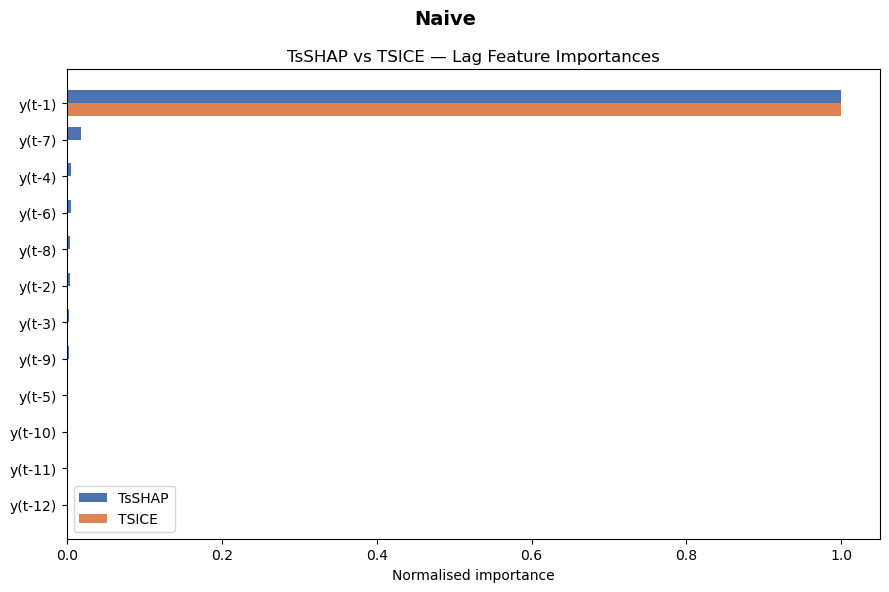

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_comparison(
    result.feature_importance,
    tsice_imp,
    top_n=12,
    ax=ax,
    title='TsSHAP vs TSICE — Lag Feature Importances',
)
fig.suptitle('Naive', fontsize=14, fontweight='bold')
fig.subplots_adjust(top=0.88)
plt.show()

## Comparison across forecasters

The loop below evaluates **every** forecaster exported from `tsshap.forecasters` using the same lag / seasonal-lag TsSHAP feature set and horizon as the single-forecaster demos above.


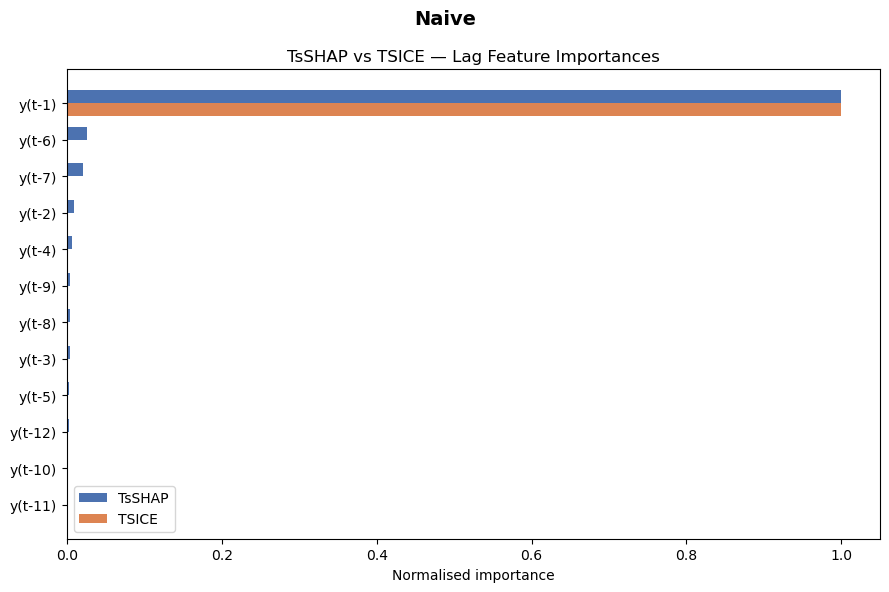

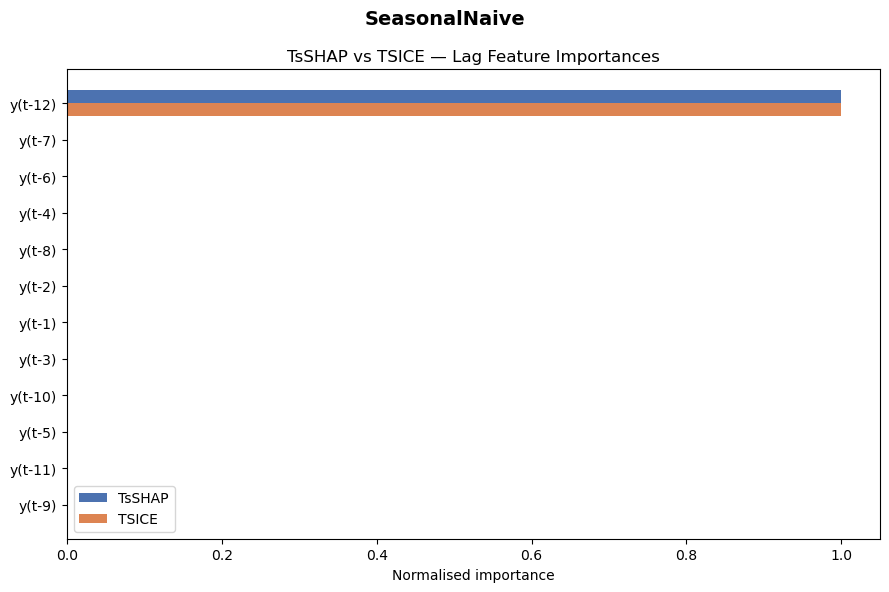

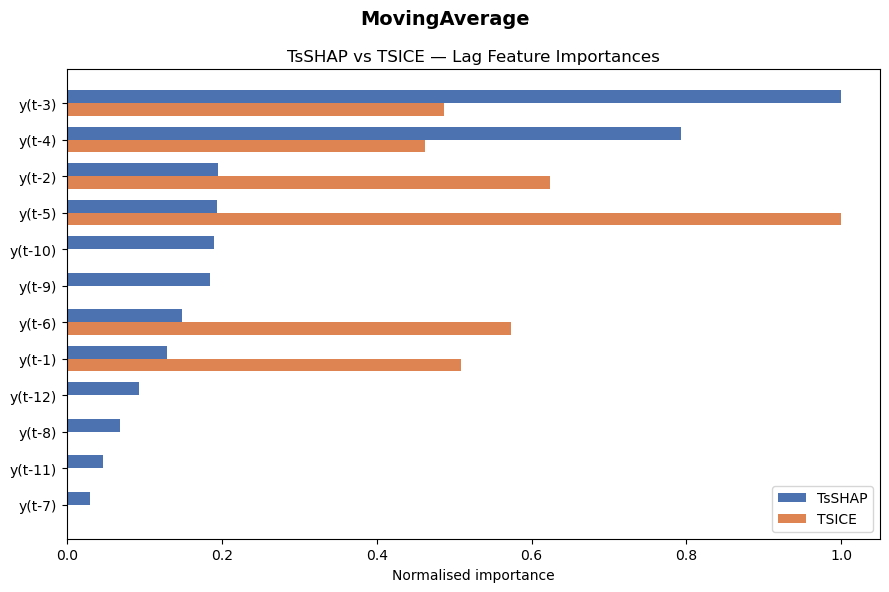

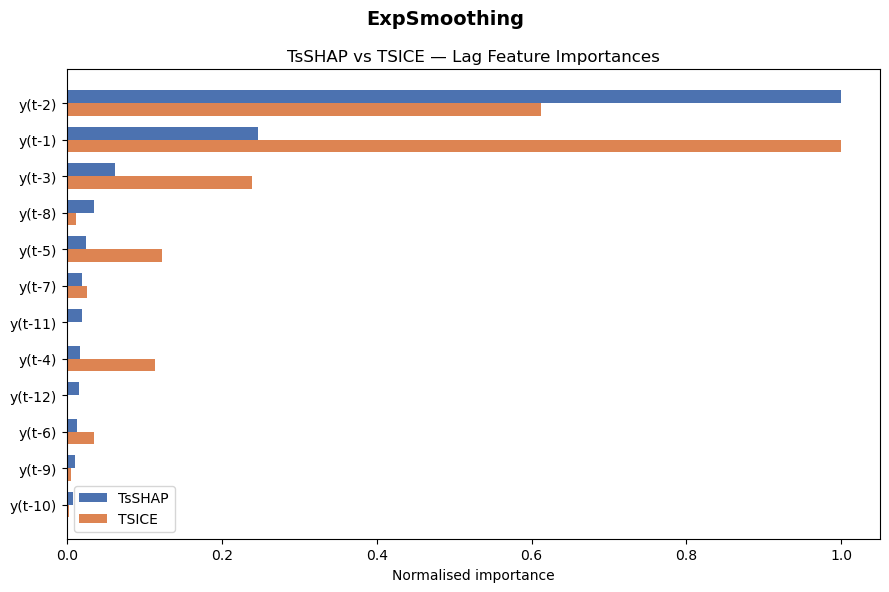

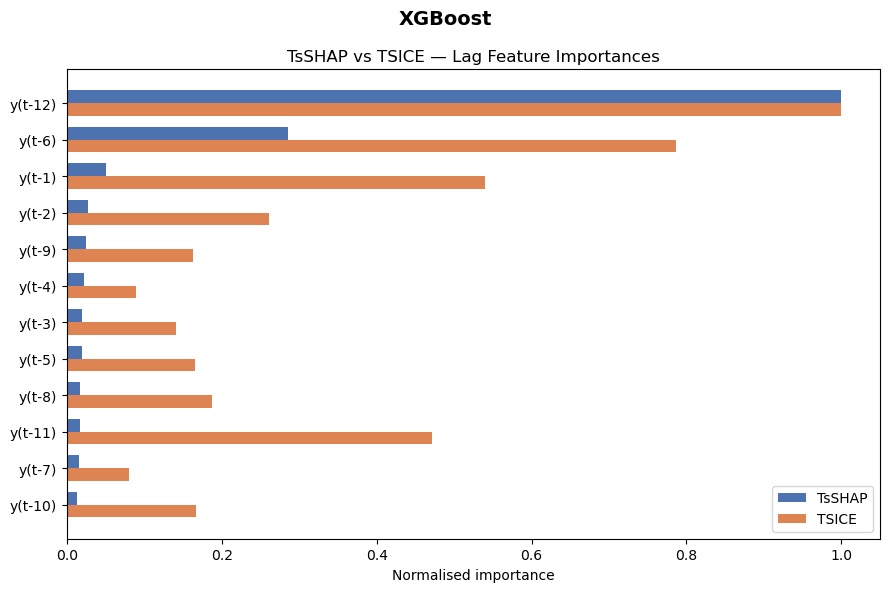

Importing plotly failed. Interactive plots will not work.
02:22:23 - cmdstanpy - INFO - Chain [1] start processing
02:22:23 - cmdstanpy - INFO - Chain [1] done processing
02:22:23 - cmdstanpy - INFO - Chain [1] start processing
02:22:23 - cmdstanpy - INFO - Chain [1] done processing
02:22:23 - cmdstanpy - INFO - Chain [1] start processing
02:22:23 - cmdstanpy - INFO - Chain [1] done processing
02:22:23 - cmdstanpy - INFO - Chain [1] start processing
02:22:23 - cmdstanpy - INFO - Chain [1] done processing
02:22:23 - cmdstanpy - INFO - Chain [1] start processing
02:22:23 - cmdstanpy - INFO - Chain [1] done processing
02:22:23 - cmdstanpy - INFO - Chain [1] start processing
02:22:29 - cmdstanpy - INFO - Chain [1] done processing
02:22:29 - cmdstanpy - INFO - Chain [1] start processing
02:22:35 - cmdstanpy - INFO - Chain [1] done processing
02:22:35 - cmdstanpy - INFO - Chain [1] start processing
02:22:35 - cmdstanpy - INFO - Chain [1] done processing
02:22:35 - cmdstanpy - INFO - Chain [1

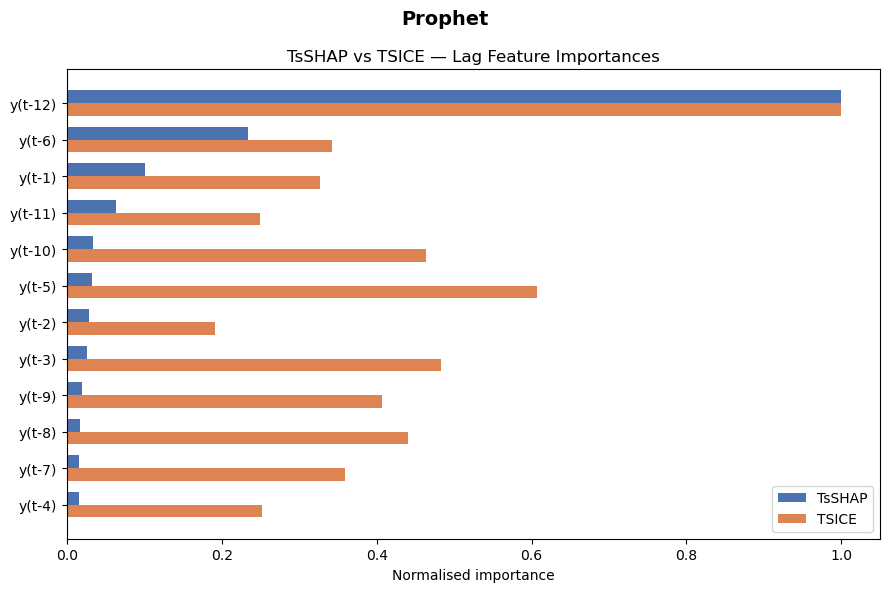

In [7]:
for fc_name, fc in [
    ('Naive', NaiveForecaster()),
    ('SeasonalNaive', SeasonalNaiveForecaster(period=12)),
    ('MovingAverage', MovingAverageForecaster(k=6)),
    ('ExpSmoothing', ExponentialSmoothingForecaster(alpha=0.5)),
    ('XGBoost', XGBoostForecaster(lags=12)),
    ('Prophet', ProphetForecaster()),
]:
    exp = TsSHAPExplainer(
        forecaster=fc,
        feature_extractors=[LagFeatures(lags=12), SeasonalLagFeatures(lags=1, period=12)],
        horizon=6,
    )
    exp.fit(y)
    r = exp.explain(scope='global')

    tsice = run_tsice(y=y, forecaster=fc, horizon=1, n_samples=10)

    # Plot the importance differences
    fig, ax = plt.subplots(figsize=(9, 6))
    plot_comparison(
        r.feature_importance,
        tsice,
        top_n=12,
        ax=ax,
        title='TsSHAP vs TSICE — Lag Feature Importances',
    )
    fig.suptitle(fc_name, fontsize=14, fontweight='bold')
    fig.subplots_adjust(top=0.88)
    plt.show()